<a href="https://colab.research.google.com/github/eospgonz10/DL_BrainTumor/blob/main/03%20-%20arquitectura%20de%20linea%20de%20base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 - Arquitectura de linea de base: Arquitetura con capas convolucionales y pooling, entrenada desde cero.

## Importes y Configuración

In [ ]:
# Librerías
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import sklearn

# TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy

import warnings
warnings.filterwarnings('ignore')

# Versiones
print(f"TensorFlow: {tf.__version__}")
print(f"Python: {sys.version}")

# Configurar TensorFlow
tf.config.threading.set_inter_op_parallelism_threads(4)
tf.config.threading.set_intra_op_parallelism_threads(4)

TensorFlow: 2.21.0
Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


## Cargar Información

Necesitamos replicar la creación de datasets del notebook 02 para tener los datos listos

In [ ]:
# Opción: Importar directamente desde notebook 02 o recrear aquí
# Para esta fase, recrearemos el pipeline de manera condensada

import kagglehub
from PIL import Image
from tensorflow.keras.applications import efficientnet

print("Descargando dataset...")
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
data_dir = Path(path)

# Buscar carpetas
training_dir = None
for root, dirs, files in os.walk(data_dir):
    if 'Training' in dirs:
        training_dir = Path(root) / 'Training'
        break

print(f"✓ Dataset disponible")
print(f"✓ Training dir: {training_dir}")

# Obtener clases
class_names = sorted([d.name for d in training_dir.iterdir() if d.is_dir()])
NUM_CLASSES = len(class_names)
print(f"\n✓ Clases ({NUM_CLASSES}): {class_names}")

Descargando dataset...
✓ Dataset disponible
✓ Training dir: C:\Users\lolop\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2\Training

✓ Clases (4): ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
def load_and_preprocess_image(image_path, target_size=(380, 380)):
    try:
        img = Image.open(image_path)

        # Convertir a gris
        if img.mode != 'L':
            img = img.convert('L')

        # Resize
        img = img.resize(target_size, Image.LANCZOS)

        # Convertir a RGB (replicar canal gris)
        img_array = np.array(img, dtype=np.float32)
        img_rgb = np.stack([img_array, img_array, img_array], axis=-1)

        # Normalización ImageNet (preprocess_input)
        img_preprocessed = efficientnet.preprocess_input(img_rgb)

        return img_preprocessed
    except Exception as e:
        print(f"Error: {e}")
        return None

print("✓ Función de preprocesamiento definida")

✓ Función de preprocesamiento definida


In [ ]:
import random

random.seed(42)
np.random.seed(42)

class_to_idx = {name: idx for idx, name in enumerate(class_names)}

# Recopilar imágenes
all_images_by_class = {}
for class_name in class_names:
    class_dir = training_dir / class_name
    image_files = sorted(
        list(class_dir.glob('*.jpg')) +
        list(class_dir.glob('*.png')) +
        list(class_dir.glob('*.jpeg'))
    )
    all_images_by_class[class_name] = image_files

# Split estratificado
train_paths, train_labels = [], []
val_paths, val_labels = [], []
test_paths, test_labels = [], []

for class_name, image_files in all_images_by_class.items():
    indices = list(range(len(image_files)))
    random.shuffle(indices)

    n = len(image_files)
    train_end = int(n * 0.70)
    val_end = train_end + int(n * 0.15)

    label = class_to_idx[class_name]

    for i in indices[:train_end]:
        train_paths.append(str(image_files[i]))
        train_labels.append(label)

    for i in indices[train_end:val_end]:
        val_paths.append(str(image_files[i]))
        val_labels.append(label)

    for i in indices[val_end:]:
        test_paths.append(str(image_files[i]))
        test_labels.append(label)

print(f"\nSplit 70/15/15 creado:")
print(f"  Train: {len(train_paths)}")
print(f"  Val:   {len(val_paths)}")
print(f"  Test:  {len(test_paths)}")


Split 70/15/15 creado:
  Train: 3916
  Val:   840
  Test:  844


In [ ]:
def create_tf_dataset(image_paths, labels, class_names,
                      is_training=False, batch_size=32):
    """
    Crea dataset tf.data (versión simplificada sin augmentation para FASE 1)
    """

    def load_image_and_label(image_path, label):
        image_str = image_path.numpy() if isinstance(image_path, tf.Tensor) else image_path
        image = load_and_preprocess_image(image_str, target_size=(380, 380))

        if image is None:
            image = np.zeros((380, 380, 3), dtype=np.float32)

        label_onehot = tf.keras.utils.to_categorical(label, num_classes=len(class_names))
        return image, label_onehot

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(
        lambda img_path, label: tf.py_function(
            load_image_and_label,
            [img_path, label],
            [tf.float32, tf.float32]
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    dataset = dataset.map(
        lambda img, label: (
            tf.ensure_shape(img, (380, 380, 3)),
            tf.ensure_shape(label, (len(class_names),))
        )
    )

    if is_training:
        dataset = dataset.shuffle(buffer_size=len(image_paths))

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

BATCH_SIZE = 16  # Reducido de 32 para estabilidad en CPU

print("Creando datasets...")
train_dataset = create_tf_dataset(train_paths, train_labels, class_names, is_training=True, batch_size=BATCH_SIZE)
val_dataset = create_tf_dataset(val_paths, val_labels, class_names, is_training=False, batch_size=BATCH_SIZE)
test_dataset = create_tf_dataset(test_paths, test_labels, class_names, is_training=False, batch_size=BATCH_SIZE)

print(f"✓ Datasets creados")
print(f"  Train: {len(train_paths)//BATCH_SIZE} batches")
print(f"  Val:   {len(val_paths)//BATCH_SIZE} batches")
print(f"  Test:  {len(test_paths)//BATCH_SIZE} batches")

Creando datasets...
✓ Datasets creados
  Train: 244 batches
  Val:   52 batches
  Test:  52 batches


## Construccion de la arquitectura propia

In [ ]:
optimizer = Adam(
    learning_rate=1e-3,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7,
    clipnorm=1.0,
    name='Adam_TL'
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Input image dimensions
IMG_HEIGHT, IMG_WIDTH = 380, 380
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)

# Define the Baseline CNN Model
def create_baseline_cnn_model(num_classes):
    model = Sequential([
        # First Convolutional Block
        Conv2D(32, (3, 3), activation='relu', input_shape=INPUT_SHAPE),
        MaxPooling2D((2, 2)),

        # Second Convolutional Block
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # Third Convolutional Block
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # Fourth Convolutional Block
        Conv2D(256, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # Flatten and Dense layers
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5), # Add dropout for regularization
        Dense(num_classes, activation='softmax') # Output layer for 4 classes
    ])
    return model

# Create the model instance
model = create_baseline_cnn_model(NUM_CLASSES)

# Compile the model
model.compile(optimizer=optimizer,
              loss=CategoricalCrossentropy(),
                  metrics=[
        CategoricalAccuracy(name='accuracy'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ])
# Display the model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 378, 378, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 189, 189, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 187, 187, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 93, 93, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 91, 91, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 43, 43, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 21, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 112896)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    28,901,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,291,076 (111.74 MB)

 Trainable params: 29,291,076 (111.74 MB)

 Non-trainable params: 0 (0.00 B)

## Validar con un Batch de Entrenamiento

In [ ]:
print("\n" + "="*70)
print("VALIDACIÓN: FORWARD PASS CON BATCH DE ENTRENAMIENTO")
print("="*70)

# Obtener un batch
sample_images, sample_labels = next(iter(train_dataset))

print(f"\nBatch shape:")
print(f"  Imágenes: {sample_images.shape}")
print(f"  Labels: {sample_labels.shape}")

# Forward pass (predicción sin entrenar)
print(f"\nRealizando forward pass (sin entrenar modelo aún)...")
predictions = model.predict(sample_images, verbose=0)

print(f"\n✓ Forward pass exitoso")
print(f"  Output shape: {predictions.shape}")
print(f"  Número de predicciones: {len(predictions)}")
print(f"  Número de clases: {predictions.shape[1]}")
print(f"\nPrimera predicción (sin entrenar):")
print(f"  Probabilidades: {predictions[0]}")
print(f"  Clase predicha: {class_names[np.argmax(predictions[0])]}")
print(f"  Confianza: {np.max(predictions[0])*100:.1f}%")


VALIDACIÓN: FORWARD PASS CON BATCH DE ENTRENAMIENTO

Batch shape:
  Imágenes: (16, 380, 380, 3)
  Labels: (16, 4)

Realizando forward pass (sin entrenar modelo aún)...

✓ Forward pass exitoso
  Output shape: (16, 4)
  Número de predicciones: 16
  Número de clases: 4

Primera predicción (sin entrenar):
  Probabilidades: [3.9464328e-01 4.1147650e-05 6.0531557e-01 3.7192655e-10]
  Clase predicha: notumor
  Confianza: 60.5%


In [ ]:
model.save('baseline_cnn_model.h5')

## Entrenamiento del modelo

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from datetime import datetime

# Crear directorio para checkpoints
checkpoint_dir = Path('checkpoints')
checkpoint_dir.mkdir(exist_ok=True)

# EarlyStopping: Detener si no hay mejora
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: Reducir learning rate si no hay mejora
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# ModelCheckpoint: Guardar mejor modelo
model_checkpoint = ModelCheckpoint(
    f'{checkpoint_dir}/mejor_modelo.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, reduce_lr, model_checkpoint]

In [ ]:
# Configuración de entrenamiento
EPOCHS = 5  # Test inicial (reducido de 25 para diagnosticar)
print(f"\nConfiguración:")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: 1e-3")

# Entrenar
print(f"\n" + "="*70)
print(f"INICIANDO ENTRENAMIENTO...")
print(f"="*70)

# Memory optimization
import gc
gc.collect()
tf.keras.backend.clear_session()

start_time = datetime.now()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

end_time = datetime.now()
training_time = (end_time - start_time).total_seconds() / 60

print(f"\n✓ Entrenamiento completado en {training_time:.2f} minutos")


Configuración:
  Epochs: 5
  Batch size: 16
  Learning rate: 1e-3

INICIANDO ENTRENAMIENTO...



Epoch 1/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5683 - loss: 35.4148 - precision: 0.6142 - recall: 0.4636
Epoch 1: val_accuracy improved from None to 0.82976, saving model to checkpoints/mejor_modelo.h5



Epoch 1: finished saving model to checkpoints/mejor_modelo.h5
245/245 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.6994 - loss: 7.9421 - precision: 0.7522 - recall: 0.6210 - val_accuracy: 0.8298 - val_loss: 0.4726 - val_precision: 0.8606 - val_recall: 0.8012 - learning_rate: 0.0010
Epoch 2/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8422 - loss: 0.4960 - precision: 0.8666 - recall: 0.8102
Epoch 2: val_accuracy improved from 0.82976 to 0.85595, saving model to checkpoints/mejor_modelo.h5



Epoch 2: finished saving model to checkpoints/mejor_modelo.h5
245/245 ━━━━━━━━━━━━━━━━━━━━ 278s 1s/step - accuracy: 0.8470 - loss: 0.4899 - precision: 0.8732 - recall: 0.8174 - val_accuracy: 0.8560 - val_loss: 0.4102 - val_precision: 0.8613 - val_recall: 0.8500 - learning_rate: 0.0010
Epoch 3/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 855ms/step - accuracy: 0.8727 - loss: 0.3573 - precision: 0.8894 - recall: 0.8633
Epoch 3: val_accuracy did not improve from 0.85595
245/245 ━━━━━━━━━━━━━━━━━━━━ 222s 892ms/step - accuracy: 0.8779 - loss: 0.3598 - precision: 0.8920 - recall: 0.8672 - val_accuracy: 0.7560 - val_loss: 0.5954 - val_precision: 0.7836 - val_recall: 0.7417 - learning_rate: 0.0010
Epoch 4/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - accuracy: 0.9036 - loss: 0.3015 - precision: 0.9141 - recall: 0.8976
Epoch 4: val_accuracy did not improve from 0.85595
245/245 ━━━━━━━━━━━━━━━━━━━━ 219s 879ms/step - accuracy: 0.9119 - loss: 0.3092 - precision: 0.9195 - recall: 0.9065 - val_accuracy: 0.85


Epoch 5: finished saving model to checkpoints/mejor_modelo.h5
245/245 ━━━━━━━━━━━━━━━━━━━━ 220s 882ms/step - accuracy: 0.9247 - loss: 0.2347 - precision: 0.9282 - recall: 0.9206 - val_accuracy: 0.9131 - val_loss: 0.2763 - val_precision: 0.9150 - val_recall: 0.9095 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

✓ Entrenamiento completado en 20.36 minutos


## Evaluacion de la metricas finales

VISUALIZAR CONVERGENCIA DEL ENTRENAMIENTO


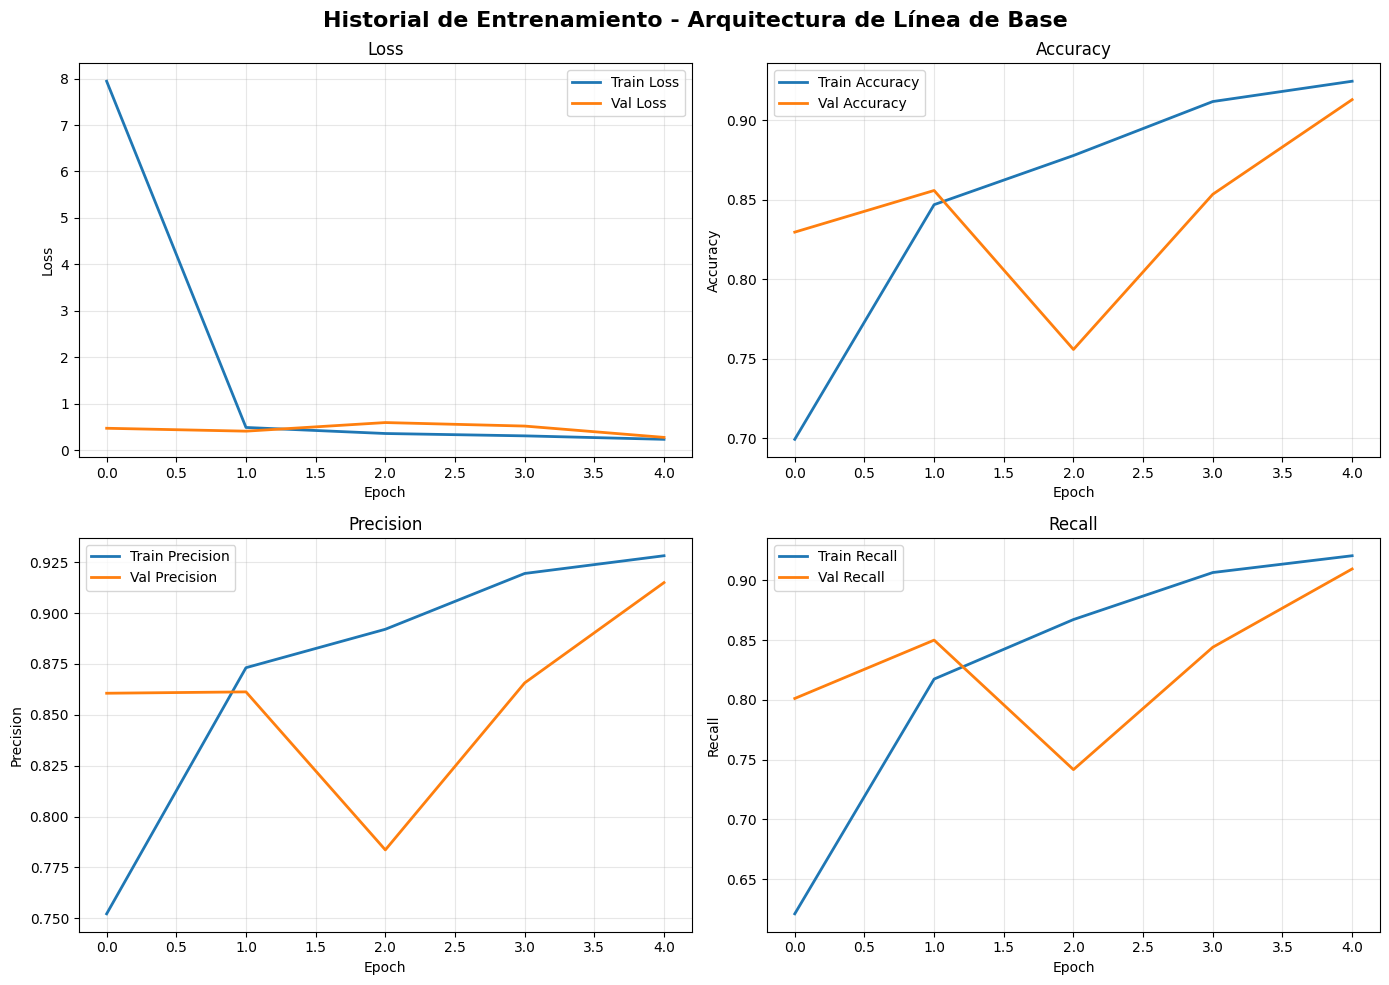


✓ Gráficas guardadas en 'historial_entrenamiento.png'


In [ ]:
print("="*70)
print("VISUALIZAR CONVERGENCIA DEL ENTRENAMIENTO")
print("="*70)

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Historial de Entrenamiento - Arquitectura de Línea de Base', fontsize=16, fontweight='bold')

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train Precision', linewidth=2)
axes[1, 0].plot(history.history['val_precision'], label='Val Precision', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train Recall', linewidth=2)
axes[1, 1].plot(history.history['val_recall'], label='Val Recall', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].set_title('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('historial_entrenamiento.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Gráficas guardadas en 'historial_entrenamiento.png'")

In [ ]:
print("="*70)
print("ESTADÍSTICAS DE ENTRENAMIENTO")
print("="*70)

# Métricas finales
final_train_loss = history.history['loss'][-1]
final_train_acc = history.history['accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]
final_val_acc = history.history['val_accuracy'][-1]

min_val_loss = min(history.history['val_loss'])
max_val_acc = max(history.history['val_accuracy'])
best_epoch = np.argmin(history.history['val_loss']) + 1

print(f"\nMétricas Finales:")
print(f"  Train Loss: {final_train_loss:.4f}")
print(f"  Train Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"  Val Loss: {final_val_loss:.4f}")
print(f"  Val Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")

print(f"\nMejores Resultados:")
print(f"  Mejor Val Loss: {min_val_loss:.4f} (Epoch {best_epoch})")
print(f"  Mejor Val Accuracy: {max_val_acc:.4f} ({max_val_acc*100:.2f}%)")

print(f"\nTiempo Total:")
print(f"  Entrenamiento: {training_time:.2f} minutos")
print(f"  Tiempo/Epoch: {training_time/len(history.history['loss']):.2f} minutos")

ESTADÍSTICAS DE ENTRENAMIENTO

Métricas Finales:
  Train Loss: 0.2347
  Train Accuracy: 0.9247 (92.47%)
  Val Loss: 0.2763
  Val Accuracy: 0.9131 (91.31%)

Mejores Resultados:
  Mejor Val Loss: 0.2763 (Epoch 5)
  Mejor Val Accuracy: 0.9131 (91.31%)

Tiempo Total:
  Entrenamiento: 20.36 minutos
  Tiempo/Epoch: 4.07 minutos


In [ ]:
print("="*70)
print("EVALUAR MODELO EN TEST SET")
print("="*70)

# Evaluación
test_results = model.evaluate(test_dataset, verbose=1)

metric_names = model.metrics_names
print(f"\nMétricas en Test Set:")
for name, value in zip(metric_names, test_results):
    if name == 'accuracy':
        print(f"  {name.upper()}: {value:.4f} ({value*100:.2f}%)")
    else:
        print(f"  {name.upper()}: {value:.4f}")

EVALUAR MODELO EN TEST SET
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - accuracy: 0.8957 - loss: 0.3655 - precision: 0.9008 - recall: 0.8934

Métricas en Test Set:
  LOSS: 0.3655
  COMPILE_METRICS: 0.8957


In [ ]:
# 1) Predictions (probabilities -> class indices)
y_pred_proba = model.predict(test_dataset, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# 2) True labels (concatenate batches; labels are one-hot)# build y_true robustly (works if labels are numpy arrays or tf.Tensors)
y_true_list = []
for _, labels in test_dataset:
    if hasattr(labels, "numpy"):
        arr = labels.numpy()
    else:
        arr = labels
    y_true_list.append(np.argmax(arr, axis=1))
y_true = np.concatenate(y_true_list, axis=0)

# Quick sanity-check
print(f"Samples - y_true: {len(y_true)}, y_pred: {len(y_pred)}")

53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step
Samples - y_true: 844, y_pred: 844


In [ ]:
from sklearn.metrics import classification_report
print("="*70)
print("REPORTE DE CLASIFICACIÓN - MÉTRICAS POR CLASE")
print("="*70)

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\n" + report)

# Guardar reporte
with open('reporte_clasificacion.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print(f"✓ Reporte guardado en 'reporte_clasificacion.txt'")

REPORTE DE CLASIFICACIÓN - MÉTRICAS POR CLASE

              precision    recall  f1-score   support

      glioma     0.9231    0.8531    0.8867       211
  meningioma     0.8199    0.8199    0.8199       211
     notumor     0.9393    0.9526    0.9459       211
   pituitary     0.9018    0.9573    0.9287       211

    accuracy                         0.8957       844
   macro avg     0.8960    0.8957    0.8953       844
weighted avg     0.8960    0.8957    0.8953       844

✓ Reporte guardado en 'reporte_clasificacion.txt'


## Analisis detallado de resultados por categoria

In [ ]:
# Extraer métricas de classification_report para análisis
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=range(NUM_CLASSES), zero_division=0
)

# Crear DataFrame para visualización
metrics_df = pd.DataFrame({
    'Clase': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support.astype(int)
})

print("\n✓ Métricas Extraídas:")
print(metrics_df.to_string(index=False))
print(f"\nPromedio ponderado:")
print(f"  - Precision: {np.average(precision, weights=support):.4f}")
print(f"  - Recall: {np.average(recall, weights=support):.4f}")
print(f"  - F1-Score: {np.average(f1, weights=support):.4f}")


✓ Métricas Extraídas:
     Clase  Precision   Recall  F1-Score  Support
    glioma   0.923077 0.853081  0.886700      211
meningioma   0.819905 0.819905  0.819905      211
   notumor   0.939252 0.952607  0.945882      211
 pituitary   0.901786 0.957346  0.928736      211

Promedio ponderado:
  - Precision: 0.8960
  - Recall: 0.8957
  - F1-Score: 0.8953


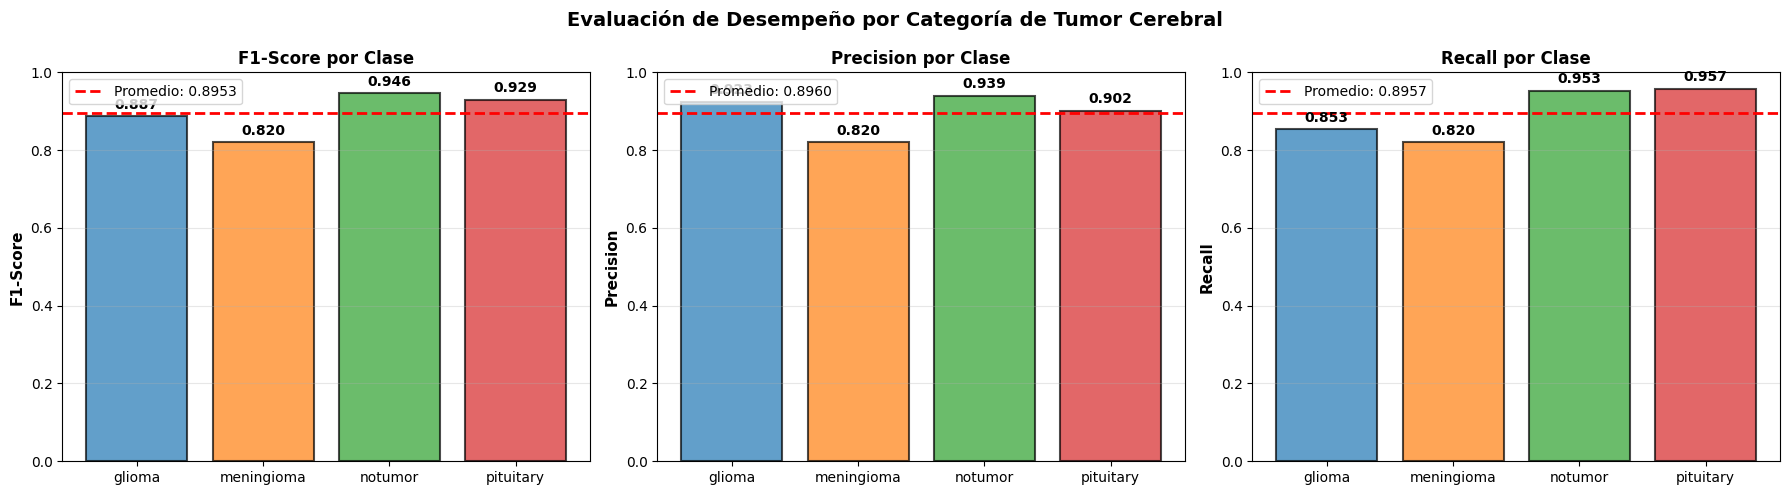

In [ ]:
# Crear figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evaluación de Desempeño por Categoría de Tumor Cerebral',
             fontsize=14, fontweight='bold')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# F1-Score
axes[0].bar(class_names, f1, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].axhline(y=np.mean(f1), color='red', linestyle='--', linewidth=2,
                label=f'Promedio: {np.mean(f1):.4f}')
axes[0].set_ylabel('F1-Score', fontsize=11, fontweight='bold')
axes[0].set_title('F1-Score por Clase', fontsize=12, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(f1):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)

# Precision
axes[1].bar(class_names, precision, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].axhline(y=np.mean(precision), color='red', linestyle='--', linewidth=2,
                label=f'Promedio: {np.mean(precision):.4f}')
axes[1].set_ylabel('Precision', fontsize=11, fontweight='bold')
axes[1].set_title('Precision por Clase', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(precision):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)

# Recall
axes[2].bar(class_names, recall, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[2].axhline(y=np.mean(recall), color='red', linestyle='--', linewidth=2,
                label=f'Promedio: {np.mean(recall):.4f}')
axes[2].set_ylabel('Recall', fontsize=11, fontweight='bold')
axes[2].set_title('Recall por Clase', fontsize=12, fontweight='bold')
axes[2].set_ylim([0, 1])
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(recall):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('metricas_por_clase_fase2a.png', dpi=300, bbox_inches='tight')
plt.show()

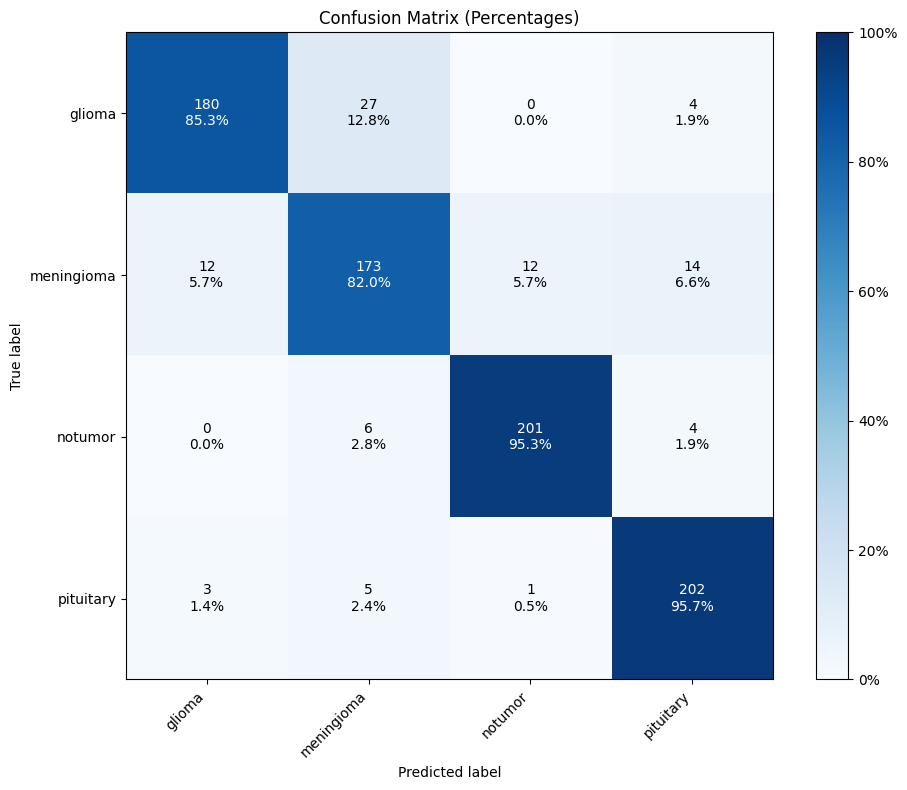

✓ Confusion matrix saved to 'confusion_matrix_percentages.png'


In [ ]:
from sklearn.metrics import confusion_matrix
from matplotlib.ticker import PercentFormatter

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
plt.title('Confusion Matrix (Percentages)')
plt.colorbar(format=PercentFormatter(xmax=1))

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)

thresh = cm_norm.max() / 2.0
for i, j in np.ndindex(cm_norm.shape):
    pct = cm_norm[i, j] * 100
    count = cm[i, j]
    text = f"{count}\n{pct:.1f}%"
    plt.text(j, i, text,
             ha='center', va='center',
             color='white' if cm_norm[i, j] > thresh else 'black',
             fontsize=10)

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('confusion_matrix_percentages.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Confusion matrix saved to 'confusion_matrix_percentages.png'")